In [ ]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

SEED = 42
np.random.seed(SEED)

print('Python:', platform.python_version())
print('pandas:', pd.__version__)
print('scikit-learn:', sklearn.__version__)

Python: 3.12.13
pandas: 2.2.2
scikit-learn: 1.6.1


In [ ]:
from sklearn.datasets import fetch_openml

ames = fetch_openml(name='house_prices', as_frame=True, version=1, parser='auto')
df = ames.frame.copy()

print(df.shape)
df.head()


(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
target = 'SalePrice'

print('Shape:', df.shape)
print('Target dtype:', df[target].dtype)

audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_n': df.isna().sum(),
    'missing_pct': 100 * df.isna().mean(),
    'unique_n': df.nunique(dropna=False)
}).sort_values('missing_pct', ascending=False)

display(audit.head(20))
print('Duplicate rows:', df.duplicated().sum())
print(df[target].describe())

Shape: (1460, 81)
Target dtype: int64


,dtype,missing_n,missing_pct,unique_n
PoolQC,object,1453,99.520548,4
MiscFeature,object,1406,96.301370,5
Alley,object,1369,93.767123,3
Fence,object,1179,80.753425,5
FireplaceQu,object,690,47.260274,6
LotFrontage,float64,259,17.739726,111
GarageFinish,object,81,5.547945,4
GarageQual,object,81,5.547945,6
GarageYrBlt,float64,81,5.547945,98
GarageType,object,81,5.547945,7


Duplicate rows: 0
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

DROP_COLS = ['Id'] if 'Id' in df.columns else []
X = df.drop(columns=[target] + DROP_COLS)
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(1168, 79) (292, 79)
(1168,) (292,)


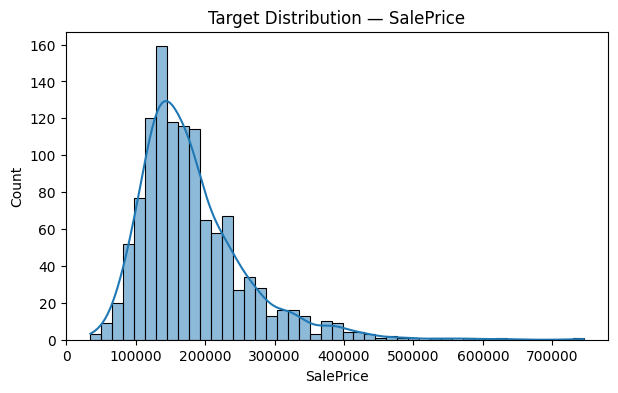

In [ ]:
train_df = X_train.copy()
train_df[target] = y_train

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(train_df[target], kde=True, ax=ax)
ax.set_title('Target Distribution — SalePrice')
plt.show()


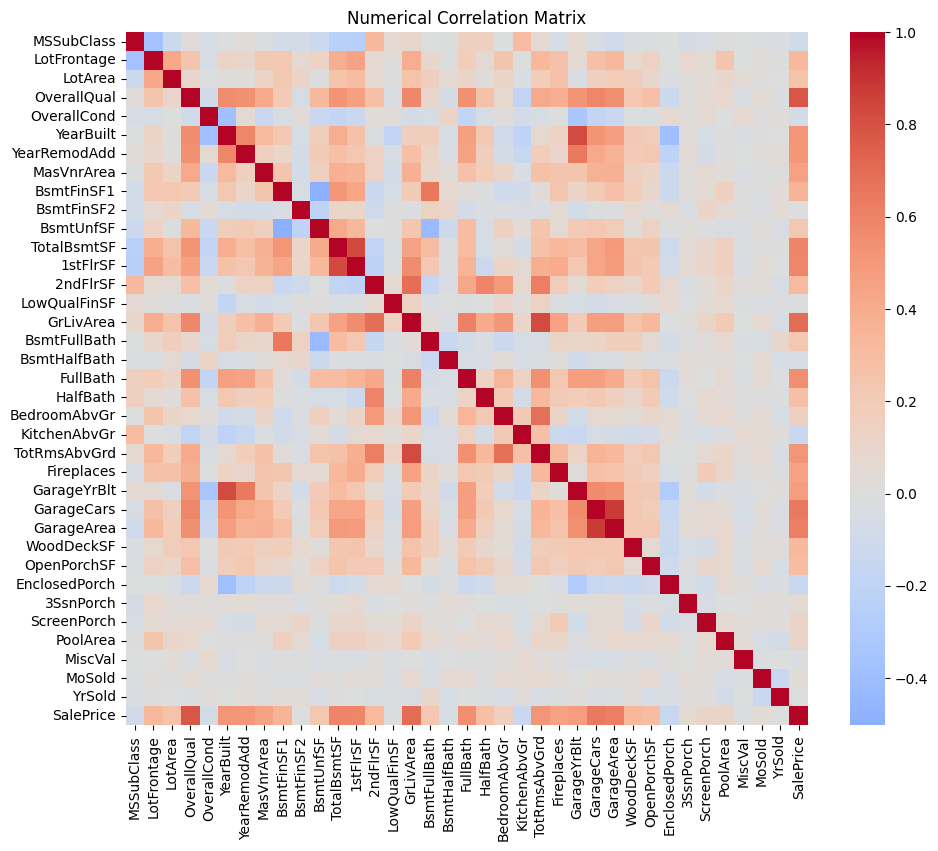

In [ ]:
num_df = train_df.select_dtypes(include=np.number)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(num_df.corr(), cmap='coolwarm', center=0, ax=ax)
ax.set_title('Numerical Correlation Matrix')
plt.show()


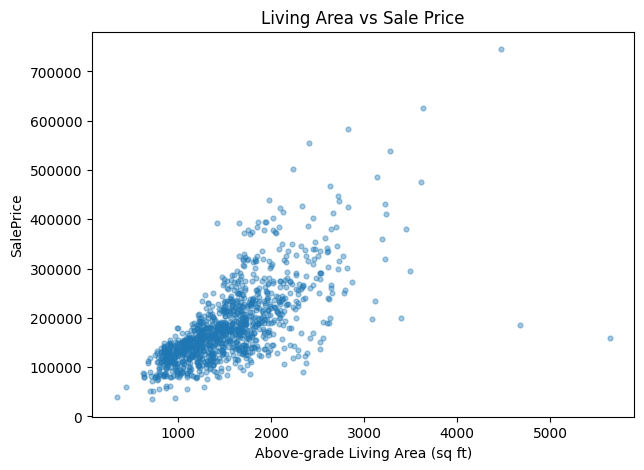

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(train_df['GrLivArea'], train_df[target], alpha=0.4, s=12)
ax.set_xlabel('Above-grade Living Area (sq ft)')
ax.set_ylabel('SalePrice')
ax.set_title('Living Area vs Sale Price')
plt.show()


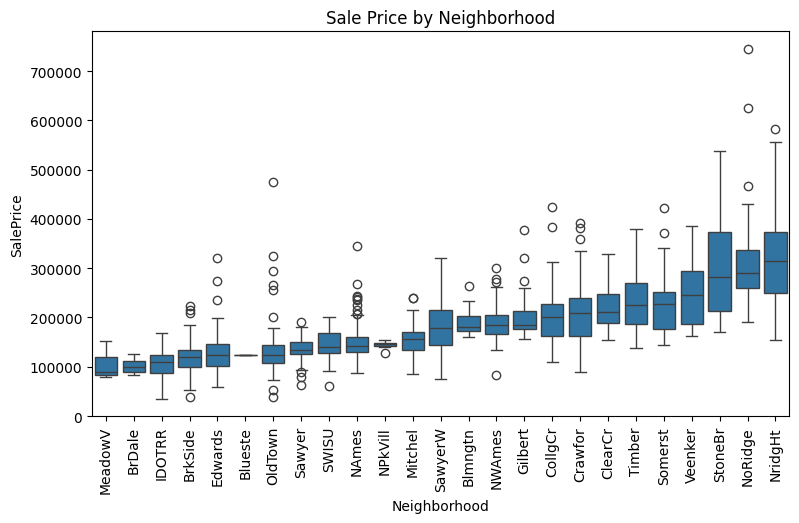

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
order = train_df.groupby('Neighborhood')[target].median().sort_values().index
sns.boxplot(data=train_df, x='Neighborhood', y=target, order=order, ax=ax)
ax.set_title('Sale Price by Neighborhood')
plt.xticks(rotation=90)
plt.show()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocess = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
], remainder='drop')

print('Numeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))

Numeric features: 36
Categorical features: 43


In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

naive = DummyRegressor(strategy='mean')
naive.fit(X_train[numeric_features], y_train)
naive_pred = naive.predict(X_test[numeric_features])

naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))
print('Naive MAE:', naive_mae)
print('Naive RMSE:', naive_rmse)

Naive MAE: 62575.926451960964
Naive RMSE: 87619.03450611533


In [ ]:
from sklearn.linear_model import LinearRegression

simple_feature = 'GrLivArea'
simple_model = LinearRegression()
simple_model.fit(X_train[[simple_feature]], y_train)
simple_pred = simple_model.predict(X_test[[simple_feature]])

print('Intercept:', simple_model.intercept_)
print('Slope:', simple_model.coef_[0])

simple_mae = mean_absolute_error(y_test, simple_pred)
simple_rmse = np.sqrt(mean_squared_error(y_test, simple_pred))
simple_r2 = r2_score(y_test, simple_pred)
print(f'MAE: {simple_mae:.4f}  RMSE: {simple_rmse:.4f}  R2: {simple_r2:.4f}')

Intercept: 24899.74815733818
Slope: 102.48895891672333
MAE: 38341.2045  RMSE: 58471.7565  R2: 0.5543


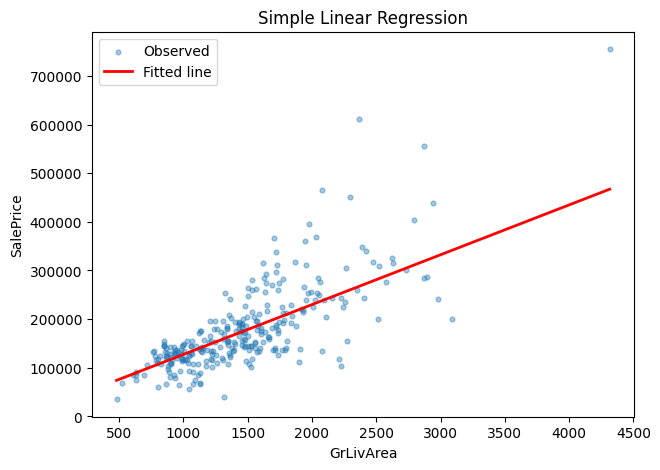

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_test[simple_feature], y_test, alpha=0.4, s=12, label='Observed')
order = np.argsort(X_test[simple_feature].to_numpy())
ax.plot(X_test[simple_feature].to_numpy()[order], simple_pred[order], linewidth=2, color='red', label='Fitted line')
ax.set_xlabel(simple_feature)
ax.set_ylabel(target)
ax.set_title('Simple Linear Regression')
ax.legend()
plt.show()

In [ ]:

linear_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', LinearRegression())
])
linear_pipeline.fit(X_train, y_train)
linear_pred = linear_pipeline.predict(X_test)

lr_mae = mean_absolute_error(y_test, linear_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
lr_r2 = r2_score(y_test, linear_pred)
print(f'MAE: {lr_mae:.4f}  RMSE: {lr_rmse:.4f}  R2: {lr_r2:.4f}')

MAE: 18361.8714  RMSE: 29447.2954  R2: 0.8869


In [ ]:
def evaluate_regressor(name, fitted_model, X_eval, y_eval):
    pred = fitted_model.predict(X_eval)
    mae = mean_absolute_error(y_eval, pred)
    mse = mean_squared_error(y_eval, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_eval, pred)
    Xt = fitted_model.named_steps['preprocess'].transform(X_eval)
    n, p = Xt.shape
    adj_r2 = np.nan if n <= p + 1 else 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'Adjusted_R2': adj_r2}, pred


In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

model_specs = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001, max_iter=20000),
    'Elastic Net': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000),
    'Decision Tree': DecisionTreeRegressor(max_depth=6, random_state=SEED),
    'Random Forest': RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=SEED)
}

fitted_models = {}
results = []
predictions = {}

for name, estimator in model_specs.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', estimator)])
    pipe.fit(X_train, y_train)
    row, pred = evaluate_regressor(name, pipe, X_test, y_test)
    results.append(row)
    fitted_models[name] = pipe
    predictions[name] = pred

results_df = pd.DataFrame(results).sort_values('RMSE')
results_df


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.411e+10, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


,Model,MAE,MSE,RMSE,R2,Adjusted_R2
6,Gradient Boosting,16695.021888,7.389373e+08,27183.401240,0.903663,-4.606822
2,Lasso,18085.680604,8.016237e+08,28312.960728,0.895490,-5.082466
5,Random Forest,17555.740702,8.393807e+08,28972.067071,0.890568,-5.368954
0,Linear Regression,18361.871363,8.671432e+08,29447.295376,0.886948,-5.579607
3,Elastic Net,18888.145246,8.789886e+08,29647.741806,0.885404,-5.669486
1,Ridge,19096.237949,8.866974e+08,29777.463894,0.884399,-5.727978
4,Decision Tree,25552.139651,1.347170e+09,36703.819494,0.824366,-9.221901


In [ ]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}

cv_rows = []
for name, estimator in model_specs.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', estimator)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        'Model': name,
        'CV_MAE_mean': -scores['test_mae'].mean(),
        'CV_RMSE_mean': -scores['test_rmse'].mean(),
        'CV_RMSE_std': scores['test_rmse'].std(),
        'CV_R2_mean': scores['test_r2'].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values('CV_RMSE_mean')
cv_results


,Model,CV_MAE_mean,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean
6,Gradient Boosting,16115.635936,27356.336651,5706.928552,0.870731
5,Random Forest,18212.277943,30608.075876,5009.652418,0.840330
1,Ridge,18803.648901,32953.547643,7271.717435,0.813233
3,Elastic Net,18980.175585,33739.178885,7294.177105,0.803991
2,Lasso,19607.968387,36177.191242,7453.931834,0.772934
0,Linear Regression,19728.448126,36542.980155,7517.890446,0.768060
4,Decision Tree,26604.762327,40194.867786,3387.867811,0.727167


In [ ]:
from sklearn.model_selection import GridSearchCV

ridge_pipe = Pipeline([('preprocess', preprocess), ('model', Ridge())])
ridge_grid = {'model__alpha': np.logspace(-3, 3, 13)}

search = GridSearchCV(
    ridge_pipe, param_grid=ridge_grid, scoring='neg_root_mean_squared_error',
    cv=cv, n_jobs=-1, return_train_score=True
)
search.fit(X_train, y_train)

print('Best parameters:', search.best_params_)
print('Best CV RMSE:', -search.best_score_)
best_ridge = search.best_estimator_

Best parameters: {'model__alpha': np.float64(31.622776601683793)}
Best CV RMSE: 31615.02984560969


In [ ]:
def split_metrics(model, X_train, y_train, X_test, y_test):
    rows = []
    for split_name, Xs, ys in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
        pred = model.predict(Xs)
        rows.append({
            'Split': split_name,
            'MAE': mean_absolute_error(ys, pred),
            'RMSE': np.sqrt(mean_squared_error(ys, pred)),
            'R2': r2_score(ys, pred)
        })
    return pd.DataFrame(rows)

for name in ['Linear Regression', 'Decision Tree', 'Random Forest']:
    print(name)
    display(split_metrics(fitted_models[name], X_train, y_train, X_test, y_test))

Linear Regression


,Split,MAE,RMSE,R2
0,Train,12664.339284,19503.263819,0.936227
1,Test,18361.871363,29447.295376,0.886948


Decision Tree


,Split,MAE,RMSE,R2
0,Train,17374.928013,23013.605207,0.911204
1,Test,25552.139651,36703.819494,0.824366


Random Forest


,Split,MAE,RMSE,R2
0,Train,7274.408207,13381.443481,0.969979
1,Test,17555.740702,28972.067071,0.890568


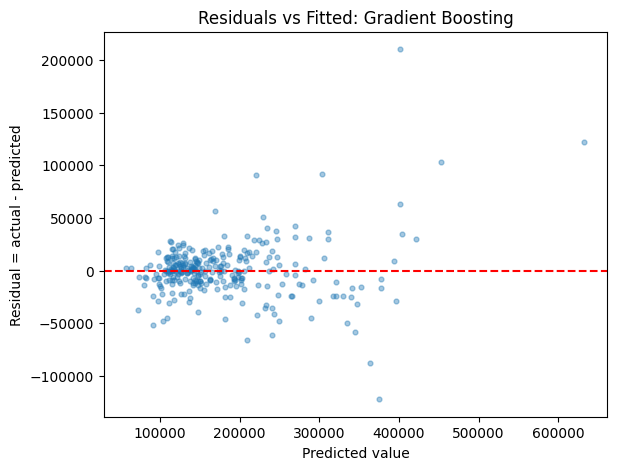

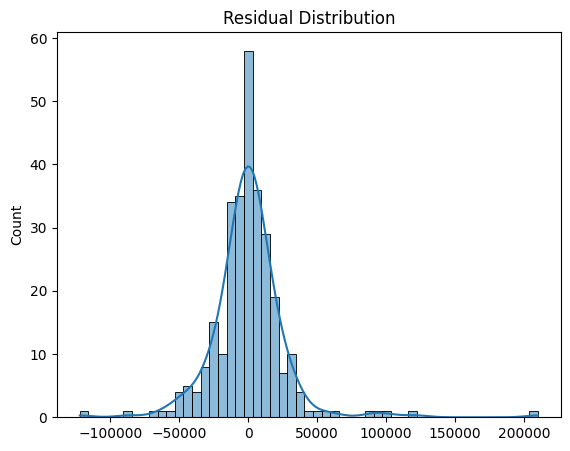

In [ ]:
selected_name = results_df.iloc[0]['Model']
y_pred = predictions[selected_name]
residuals = y_test.to_numpy() - y_pred

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(y_pred, residuals, alpha=0.4, s=12)
ax.axhline(0, linestyle='--', color='red')
ax.set_xlabel('Predicted value')
ax.set_ylabel('Residual = actual - predicted')
ax.set_title(f'Residuals vs Fitted: {selected_name}')
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.histplot(residuals, kde=True, ax=ax)
ax.set_title('Residual Distribution')
plt.show()


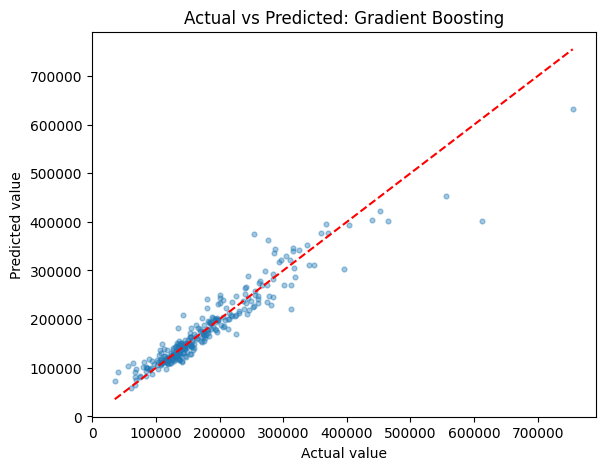

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(y_test, y_pred, alpha=0.4, s=12)
lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
ax.plot([lo, hi], [lo, hi], linestyle='--', color='red')
ax.set_xlabel('Actual value')
ax.set_ylabel('Predicted value')
ax.set_title(f'Actual vs Predicted: {selected_name}')
plt.show()

In [ ]:
best_tree_name = 'Random Forest' if 'Random Forest' in fitted_models else results_df.iloc[0]['Model']
best_tree_model = fitted_models[best_tree_name]

if hasattr(best_tree_model.named_steps['model'], 'feature_importances_'):
    feature_names = best_tree_model.named_steps['preprocess'].get_feature_names_out()
    importances = best_tree_model.named_steps['model'].feature_importances_
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    display(importance_df.head(20))

,Feature,Importance
3,num__OverallQual,0.563864
15,num__GrLivArea,0.123199
11,num__TotalBsmtSF,0.033375
13,num__2ndFlrSF,0.031621
8,num__BsmtFinSF1,0.029267
12,num__1stFlrSF,0.026000
2,num__LotArea,0.018171
26,num__GarageArea,0.015921
25,num__GarageCars,0.013905
5,num__YearBuilt,0.011558


In [ ]:
from sklearn.compose import TransformedTargetRegressor

base_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', Ridge(alpha=float(search.best_params_['model__alpha'])))
])

log_target_model = TransformedTargetRegressor(
    regressor=base_pipe,
    func=np.log1p,
    inverse_func=np.expm1
)
log_target_model.fit(X_train, y_train)
log_pred = log_target_model.predict(X_test)

log_mae = mean_absolute_error(y_test, log_pred)
log_rmse = np.sqrt(mean_squared_error(y_test, log_pred))
log_r2 = r2_score(y_test, log_pred)
print(f'Log-target Ridge — MAE: {log_mae:.4f}  RMSE: {log_rmse:.4f}  R2: {log_r2:.4f}')
print(f'(Compare to plain Ridge test RMSE from Step 11 above)')

Log-target Ridge — MAE: 16710.5549  RMSE: 25726.0175  R2: 0.9137
(Compare to plain Ridge test RMSE from Step 11 above)


In [ ]:
import json
import joblib

final_model = fitted_models[results_df.iloc[0]['Model']]  # justify your own final choice in the report

joblib.dump(final_model, 'ames_house_price_pipeline.joblib')
results_df.to_csv('ames_test_model_comparison.csv', index=False)
cv_results.to_csv('ames_cross_validation_results.csv', index=False)

run_metadata = {
    'random_seed': SEED,
    'dataset': 'Ames Housing',
    'target': target,
    'train_rows': len(X_train),
    'test_rows': len(X_test),
    'selected_model': results_df.iloc[0]['Model']
}
with open('ames_run_metadata.json', 'w') as f:
    json.dump(run_metadata, f, indent=2)

print('Artifacts saved.')

Artifacts saved.
